<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/ASGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [2]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_542/2377517764.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [3]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

print("✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!\n")

✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!



In [4]:
# ==========================================
# 4. ASGD 평균 가중치 스왑 유틸리티 + Sharpness 측정 함수
# ==========================================
import copy

@torch.no_grad()
def swap_to_averaged_weights(optimizer, model):
    """optimizer.state[p]['ax']에 저장된 평균 가중치를 모델에 임시로 로드하고,
    원래 가중치를 반환해 나중에 복원할 수 있게 한다."""
    backup = {}
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if 'ax' in state:
                backup[p] = p.data.clone()
                p.data.copy_(state['ax'])
    return backup

@torch.no_grad()
def restore_weights(model, backup):
    for p, orig in backup.items():
        p.data.copy_(orig)

@torch.no_grad()
def compute_weight_distance(optimizer):
    """raw 가중치와 ASGD 평균(ax) 가중치 사이의 전역 L2 거리.
    학습이 안정될수록(수렴할수록) 이 값이 작아지는 경향을 보인다."""
    dist_sq = 0.0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if 'ax' in state:
                dist_sq += (p.data - state['ax']).pow(2).sum().item()
    return dist_sq ** 0.5

def measure_sharpness(model_to_probe, criterion, data_loader, device, rho=0.05, n_batches=5):
    """SAM 스타일 ascent로 측정한 sharpness: L(w+eps) - L(w) 평균.
    값이 클수록 뾰족한(sharp) minima, 작을수록 평평한(flat) minima."""
    model_to_probe.eval()
    diffs = []
    it = iter(data_loader)
    for _ in range(n_batches):
        try:
            inputs, targets = next(it)
        except StopIteration:
            it = iter(data_loader)
            inputs, targets = next(it)
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            loss_w = criterion(model_to_probe(inputs), targets).item()

        model_to_probe.zero_grad()
        loss = criterion(model_to_probe(inputs), targets)
        loss.backward()

        grad_norm = torch.norm(torch.stack([
            p.grad.norm(p=2) for p in model_to_probe.parameters() if p.grad is not None
        ]), p=2)
        scale = rho / (grad_norm + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model_to_probe.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))

        with torch.no_grad():
            loss_w_eps = criterion(model_to_probe(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)

        model_to_probe.zero_grad()
        diffs.append(loss_w_eps - loss_w)

    model_to_probe.train()
    return sum(diffs) / len(diffs)

print("✅ ASGD 유틸리티(가중치 스왑, Sharpness 측정) 정의 완료!\n")

✅ ASGD 유틸리티(가중치 스왑, Sharpness 측정) 정의 완료!



In [5]:
# ==========================================
# 5. ASGD 학습 루프 (히스토리 기록 포함)
# ==========================================
def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_to_eval(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

criterion = nn.CrossEntropyLoss()
epochs = 50

# lambd: 감쇠(decay) 계수, alpha: eta 감쇠 지수, t0: 평균화를 시작하는 스텝 수
# t0을 전체 스텝 수의 약 60%에 맞춰, 학습 후반부에만 평균이 누적되도록 설정
steps_per_epoch = len(train_loader)
t0 = int(steps_per_epoch * epochs * 0.6)
t0_epoch = t0 / steps_per_epoch

optimizer = optim.ASGD(model.parameters(), lr=0.01, lambd=1e-4, alpha=0.75,
                        t0=t0, weight_decay=5e-4)

# 플롯을 위한 히스토리 기록용 딕셔너리
history = {'epoch': [], 'train_loss': [], 'test_acc_raw': [], 'test_acc_avg': [],
           'eta': [], 'mu': [], 'weight_dist': []}

print(f"🚀 CIFAR-10 학습 시작 (ASGD, t0={t0} steps / 총 {steps_per_epoch*epochs} steps, "
      f"~epoch {t0_epoch:.1f}부터 평균화 시작)...\n")

global_step = 0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

    epoch_time = time.time() - start_time
    train_loss = running_loss / len(train_loader)
    test_acc_raw = evaluate(model, test_loader)

    # ASGD 평균(ax) 가중치로 스왑해서 평가 (BN 재계산 불필요 — SWA와 달리 매 에폭 저비용으로 가능)
    backup = swap_to_averaged_weights(optimizer, model)
    test_acc_avg = evaluate(model, test_loader)
    weight_dist = compute_weight_distance(optimizer)
    restore_weights(model, backup)

    # 내부 상태(eta, mu)는 첫 번째 파라미터의 state에서 확인
    first_param = next(iter(optimizer.param_groups[0]['params']))
    p_state = optimizer.state[first_param]
    eta = p_state.get('eta', optimizer.param_groups[0]['lr'])
    mu = p_state.get('mu', 1.0)
    eta = float(eta) if not torch.is_tensor(eta) else eta.item()
    mu = float(mu) if not torch.is_tensor(mu) else mu.item()

    phase_tag = "ASGD-avg" if global_step >= t0 else "ASGD-warmup"

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['test_acc_raw'].append(test_acc_raw)
    history['test_acc_avg'].append(test_acc_avg)
    history['eta'].append(eta)
    history['mu'].append(mu)
    history['weight_dist'].append(weight_dist)

    print(f"[{phase_tag}] Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Test Acc raw: {test_acc_raw:.2f}% | "
          f"Test Acc avg: {test_acc_avg:.2f}% | eta: {eta:.5f} | mu: {mu:.4f}")

# ==========================================
# 6. 최종 평가 + Sharpness 비교
# ==========================================
raw_final_acc = evaluate(model, test_loader)
backup = swap_to_averaged_weights(optimizer, model)
avg_final_acc = evaluate(model, test_loader)

print("\n📐 Sharpness 측정 중 (raw 최종 vs ASGD 평균 최종)...")
sharpness_avg = measure_sharpness(model, criterion, train_loader, device, rho=0.05, n_batches=5)
restore_weights(model, backup)
sharpness_raw = measure_sharpness(model, criterion, train_loader, device, rho=0.05, n_batches=5)

print(f"\n🎉 ASGD 학습 종료!")
print(f"   - 최종 raw(마지막 스텝) 가중치 Test Acc : {raw_final_acc:.2f}% | Sharpness: {sharpness_raw:.4f}")
print(f"   - ASGD 평균(ax) 가중치 Test Acc         : {avg_final_acc:.2f}% | Sharpness: {sharpness_avg:.4f}")

🚀 CIFAR-10 학습 시작 (ASGD, t0=11730 steps / 총 19550 steps, ~epoch 30.0부터 평균화 시작)...

[ASGD-warmup] Epoch [1/50] | Time: 32.7s | Train Loss: 1.7853 | Test Acc raw: 44.20% | Test Acc avg: 44.20% | eta: 0.01000 | mu: 1.0000
[ASGD-warmup] Epoch [2/50] | Time: 32.5s | Train Loss: 1.5120 | Test Acc raw: 49.48% | Test Acc avg: 49.48% | eta: 0.00999 | mu: 1.0000
[ASGD-warmup] Epoch [3/50] | Time: 32.0s | Train Loss: 1.3899 | Test Acc raw: 53.20% | Test Acc avg: 53.20% | eta: 0.00999 | mu: 1.0000
[ASGD-warmup] Epoch [4/50] | Time: 32.7s | Train Loss: 1.3054 | Test Acc raw: 55.10% | Test Acc avg: 55.10% | eta: 0.00999 | mu: 1.0000
[ASGD-warmup] Epoch [5/50] | Time: 32.3s | Train Loss: 1.2417 | Test Acc raw: 57.57% | Test Acc avg: 57.57% | eta: 0.00999 | mu: 1.0000
[ASGD-warmup] Epoch [6/50] | Time: 32.4s | Train Loss: 1.1822 | Test Acc raw: 58.02% | Test Acc avg: 58.02% | eta: 0.00998 | mu: 1.0000
[ASGD-warmup] Epoch [7/50] | Time: 32.1s | Train Loss: 1.1354 | Test Acc raw: 61.02% | Test Acc avg: 6

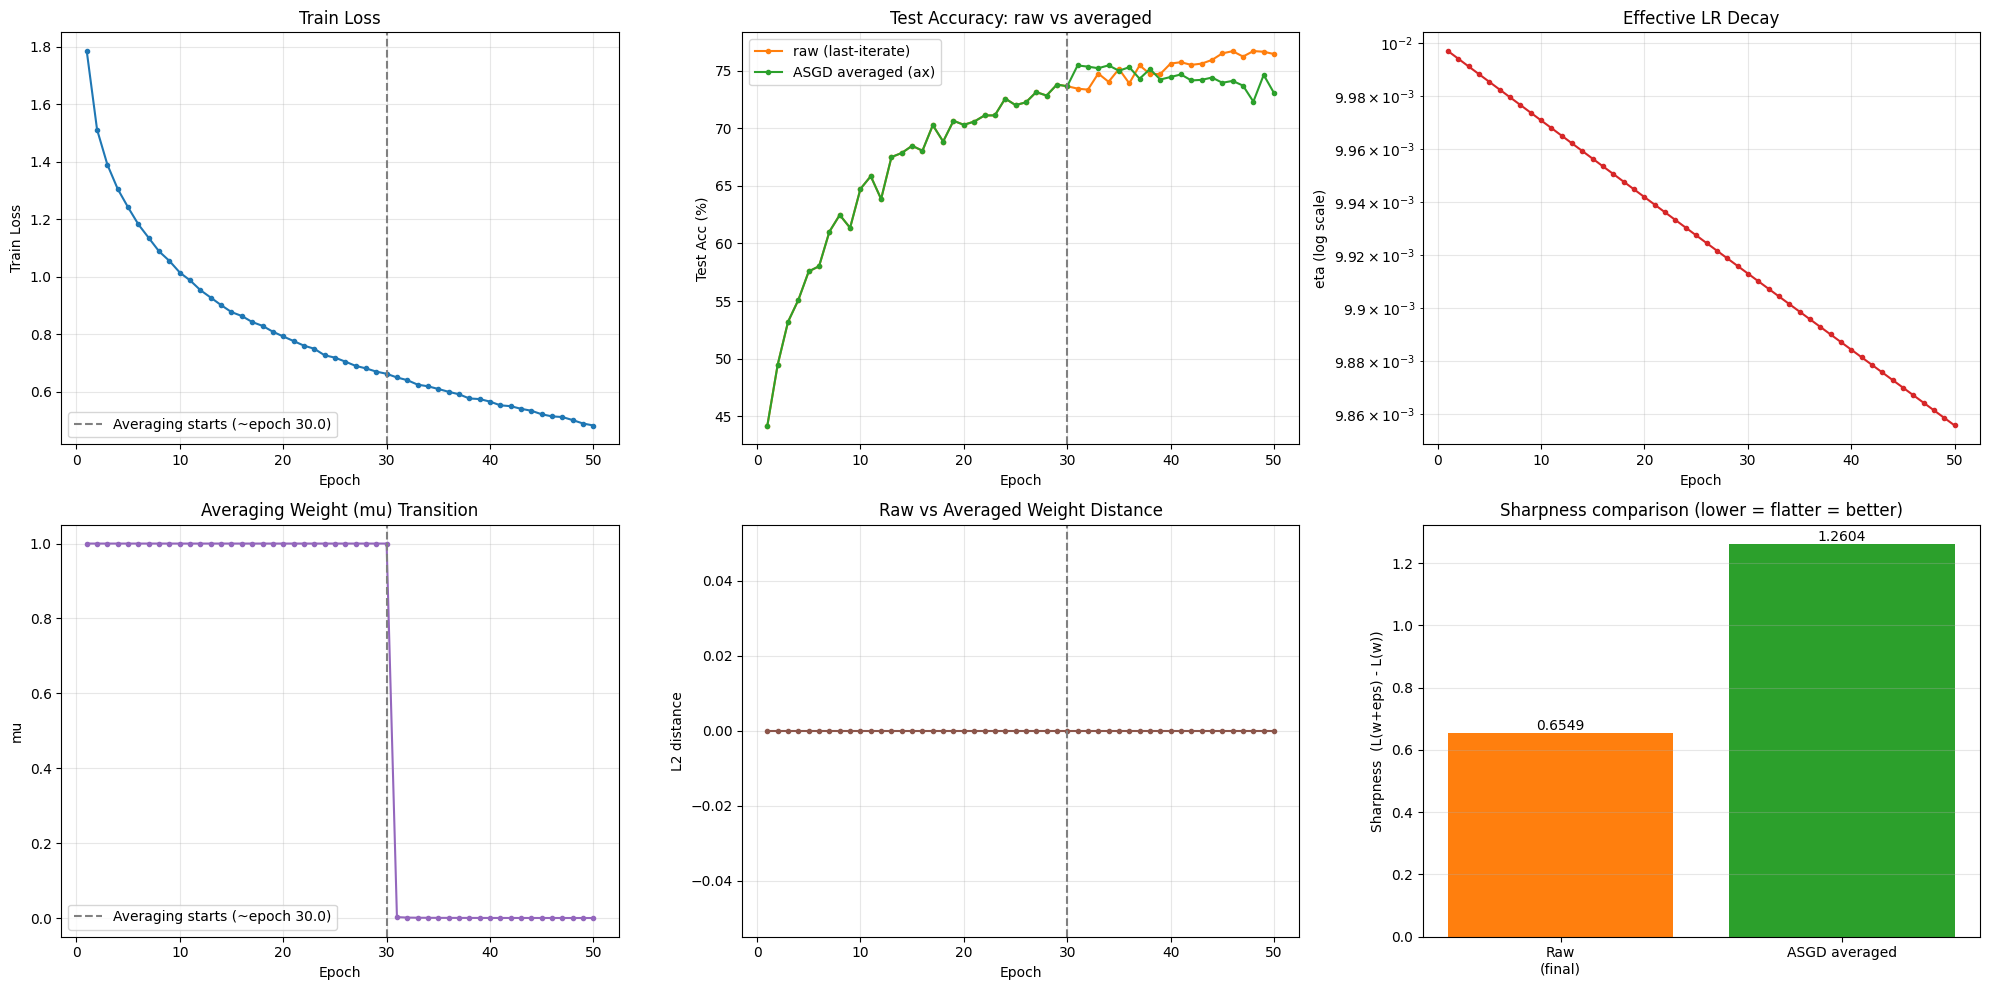


📊 요약
   - 최종 raw Test Acc          : 76.43% | Sharpness: 0.6549
   - ASGD 평균(ax) Test Acc      : 73.04% | Sharpness: 1.2604


In [6]:
# ==========================================
# 7. 결과 시각화
# ==========================================
# (참고: matplotlib 기본 폰트는 한글 글리프를 지원하지 않아 그래프 안 텍스트가
#  깨져 보일 수 있어서, 그래프 라벨/제목은 영어로 표기합니다. 콘솔 출력은 한글 그대로.)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Train Loss
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', marker='o', markersize=3)
ax.axvline(t0_epoch, color='gray', linestyle='--', label=f'Averaging starts (~epoch {t0_epoch:.1f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(); ax.grid(alpha=0.3)

# 2. Test Accuracy: raw vs averaged
ax = axes[0, 1]
ax.plot(history['epoch'], history['test_acc_raw'], color='tab:orange', marker='o', markersize=3, label='raw (last-iterate)')
ax.plot(history['epoch'], history['test_acc_avg'], color='tab:green', marker='o', markersize=3, label='ASGD averaged (ax)')
ax.axvline(t0_epoch, color='gray', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy: raw vs averaged')
ax.legend(); ax.grid(alpha=0.3)

# 3. Effective LR (eta) decay
ax = axes[0, 2]
ax.plot(history['epoch'], history['eta'], color='tab:red', marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('eta (log scale)'); ax.set_title('Effective LR Decay')
ax.grid(alpha=0.3, which='both')

# 4. Averaging weight (mu) transition
ax = axes[1, 0]
ax.plot(history['epoch'], history['mu'], color='tab:purple', marker='o', markersize=3)
ax.axvline(t0_epoch, color='gray', linestyle='--', label=f'Averaging starts (~epoch {t0_epoch:.1f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('mu'); ax.set_title('Averaging Weight (mu) Transition')
ax.legend(); ax.grid(alpha=0.3)

# 5. Raw vs averaged weight distance
ax = axes[1, 1]
ax.plot(history['epoch'], history['weight_dist'], color='tab:brown', marker='o', markersize=3)
ax.axvline(t0_epoch, color='gray', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('L2 distance'); ax.set_title('Raw vs Averaged Weight Distance')
ax.grid(alpha=0.3)

# 6. Sharpness 비교
ax = axes[1, 2]
labels = ['Raw\n(final)', 'ASGD averaged']
values = [sharpness_raw, sharpness_avg]
colors = ['tab:orange', 'tab:green']
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom')
ax.set_ylabel('Sharpness  (L(w+eps) - L(w))')
ax.set_title('Sharpness comparison (lower = flatter = better)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/asgd_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   - 최종 raw Test Acc          : {raw_final_acc:.2f}% | Sharpness: {sharpness_raw:.4f}")
print(f"   - ASGD 평균(ax) Test Acc      : {avg_final_acc:.2f}% | Sharpness: {sharpness_avg:.4f}")